In [1]:
import os
os.chdir('../../../../..')

In [2]:
import numpy as np

from sklearn.cluster import AgglomerativeClustering, SpectralClustering, DBSCAN, KMeans
from kmedoids import KMedoids
from hdbscan import HDBSCAN
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import squareform

from src.datasets import QM9Dataset
from src.helper_functions import plot_molecules_with_py3dmol, create_chemiscope_viewer, plot_distance_matrix_projection, evaluate_distance_matrix_clustering_sweep, average_numeric_by_cluster, evaluate_hdbscan_grid

In [3]:
qm9 = QM9Dataset(limit=5000, sampling_strategy="stratified", stratify_by=["num_atoms", "gap"], descriptors=["chemprop"])
df = qm9.load()
molecules = qm9.get_molecules()

2026-05-07 08:50:20.439 | INFO     | src.datasets:load:867 - Loading cached full QM9 dataset from: data/QM9/dataset_cleaned.parquet
2026-05-07 08:50:20.947 | INFO     | src.datasets:_sample_qm9_df:1073 - QM9 sampling complete: strategy=stratified, requested_limit=5000, returned_rows=5000.
2026-05-07 08:50:20.948 | INFO     | src.datasets:_add_requested_descriptors:202 - Applying requested QM9 descriptors to sampled dataframe (rows=5000).
2026-05-07 08:50:20.949 | INFO     | src.features:compute_chemprop_embeddings:709 - Computing Chemprop embeddings on mps...
2026-05-07 08:50:20.949 | INFO     | scripts.qm9.chemprop:__init__:28 - Initializing CheMeleonFingerprint generator...
2026-05-07 08:50:20.950 | INFO     | scripts.qm9.chemprop:__init__:48 - Found existing CheMeleon weights at /Users/karlfindhansen/.chemprop/chemeleon_mp.pt
2026-05-07 08:50:21.004 | SUCCESS  | scripts.qm9.chemprop:__init__:54 - Successfully loaded CheMeleon message passing weights.
2026-05-07 08:50:21.014 | INFO  

In [4]:
for i in range(1000):
    if int(df['num_atoms'].to_list()[i]) != int(len(df['coordinates'].to_list()[i])):
        print(df['mol_id'].to_list()[i])
        break

qm9_567


In [5]:
k=16
df['mol_id'].to_list()[k], df['num_atoms'].to_list()[k], len(df['coordinates'].to_list()[k])

('qm9_540', 16, 16)

In [6]:
len(molecules[0:2])

2

In [7]:
plot_molecules_with_py3dmol(molecules[0:3])

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [8]:
dist_matrix = qm9.get_distance_matrix(
    descriptor="chemprop",
    dist_type="euclidean",
    force_calculate=True,
    pca_components=8,
)

2026-05-07 08:50:56.798 | INFO     | src.datasets:get_distance_matrix:1479 - Applying PCA to reduce 'chemprop' to 8 dimensions.
2026-05-07 08:50:57.062 | INFO     | src.datasets:get_distance_matrix:1483 - PCA kept 44.16% of the variance for 'chemprop'.
2026-05-07 08:50:57.063 | INFO     | src.datasets:get_distance_matrix:1485 - PCA reduced 'chemprop' dimensions from 2048 to 8
2026-05-07 08:50:57.101 | INFO     | src.datasets:get_distance_matrix:1500 - Calculating distance matrix for chemprop using euclidean distance.
2026-05-07 08:50:57.437 | SUCCESS  | src.distance:_compute_and_save:74 - Saved distance matrix to data/QM9/dist_chemprop_euclidean_pca8.npy


# Determining the best number of clusters for each clustering method

Evaluating epsilon and min samples: 100%|██████████| 10/10 [00:13<00:00,  1.30s/it]


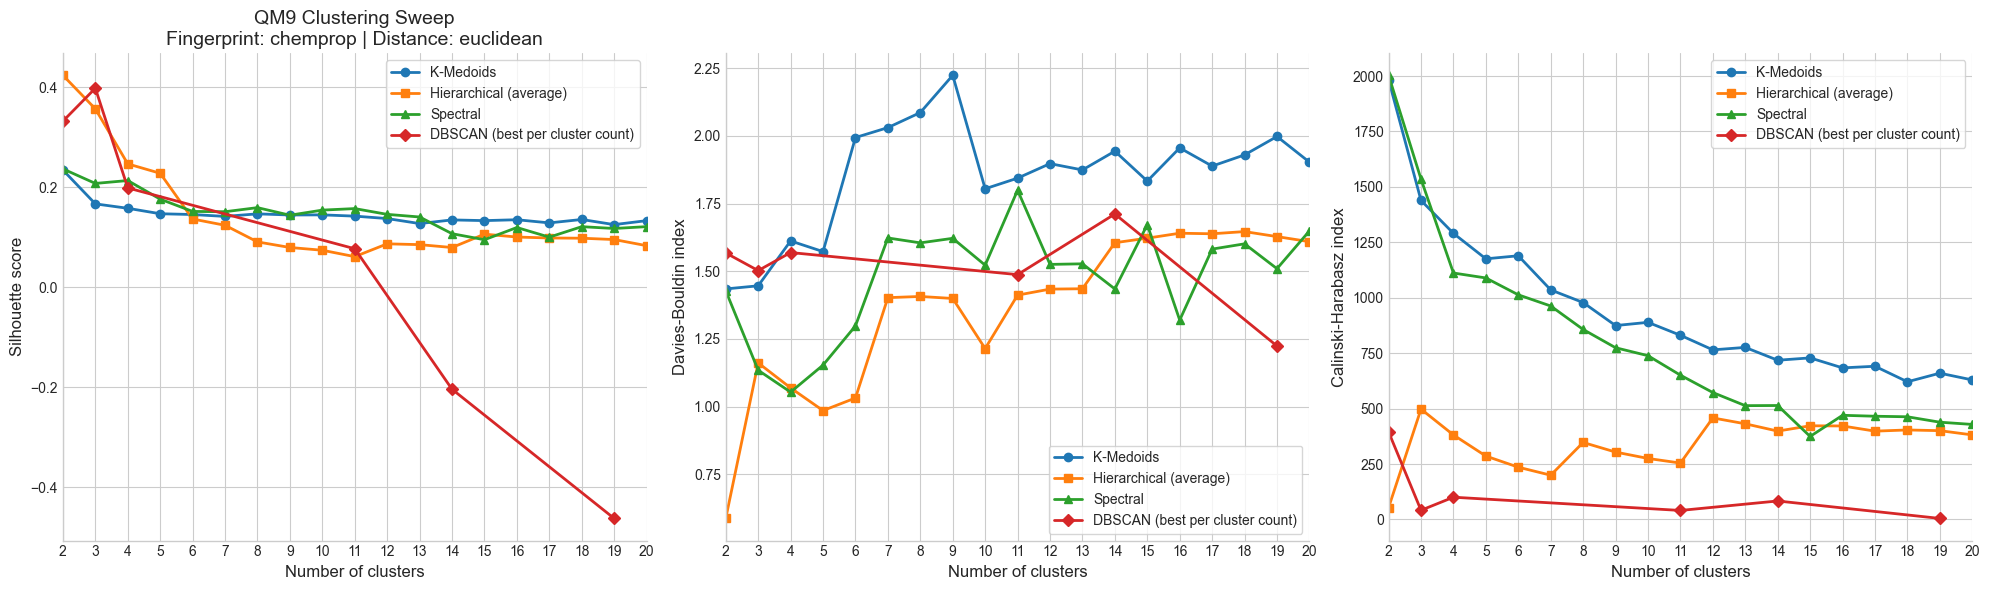

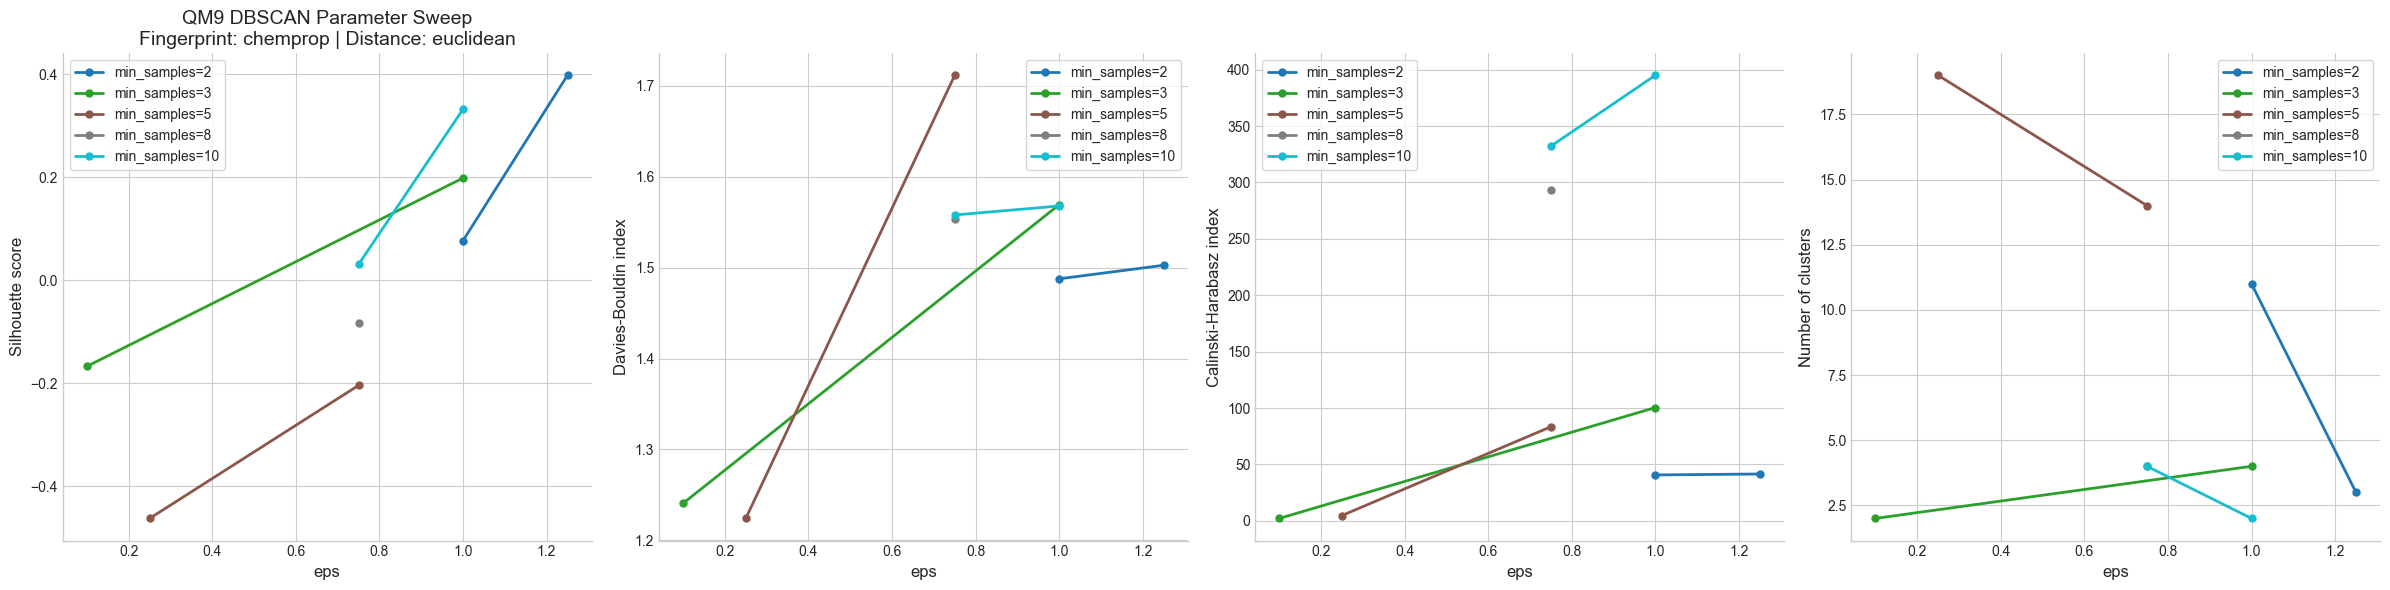

2026-05-07 08:52:45.862 | SUCCESS  | src.helper_functions:evaluate_distance_matrix_clustering_sweep:1059 - Saved clustering sweep plot to figures/qm9/clustering/euclidean/chemprop/clustering_sweep_2_to_20_clusters.png
2026-05-07 08:52:45.863 | SUCCESS  | src.helper_functions:evaluate_distance_matrix_clustering_sweep:1061 - Saved DBSCAN evaluation plot to figures/qm9/clustering/euclidean/chemprop/dbscan_parameter_sweep.png
2026-05-07 08:52:45.864 | SUCCESS  | src.helper_functions:evaluate_distance_matrix_clustering_sweep:1062 - Saved clustering sweep results to figures/qm9/clustering/euclidean/chemprop/clustering_sweep_2_to_20_clusters.json


In [9]:
out = evaluate_distance_matrix_clustering_sweep(
    dist_matrix=dist_matrix,
    fingerprint="chemprop",
    distance_metric="euclidean",
    dataset_name="qm9",
)

In [10]:
# find the n molecules that are not on the diagonal with the smallest distance
n = 10
# Get the indices of the upper triangle (excluding diagonal)
triu_indices = np.triu_indices_from(dist_matrix, k=1)
# Get the distances and corresponding molecule pairs
distances = dist_matrix[triu_indices]
molecule_pairs = list(zip(triu_indices[0], triu_indices[1]))
# Get the indices of the n smallest distances
smallest_indices = np.argsort(distances)[:n]
# Get the corresponding molecule pairs for the n smallest distances
closest_pairs = [molecule_pairs[i] for i in smallest_indices]
print("Closest molecule pairs (indices):", closest_pairs)
mols = [(molecules[idx1], molecules[idx2]) for idx1, idx2 in closest_pairs]

Closest molecule pairs (indices): [(np.int64(4856), np.int64(4857)), (np.int64(1234), np.int64(1275)), (np.int64(1197), np.int64(1271)), (np.int64(607), np.int64(717)), (np.int64(3906), np.int64(3907)), (np.int64(3795), np.int64(4425)), (np.int64(4101), np.int64(4142)), (np.int64(3196), np.int64(3221)), (np.int64(533), np.int64(537)), (np.int64(194), np.int64(195))]


In [11]:
print(mols[0])

(Atoms(symbols='NC2OCN2COH5', pbc=False, initial_charges=..., mass=..., partial_charge=...), Atoms(symbols='NC2ON2C2OH5', pbc=False, initial_charges=..., mass=..., partial_charge=...))


In [12]:
plot_molecules_with_py3dmol(mols[5])

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

# Hiercical Clustering on Distance Matrix

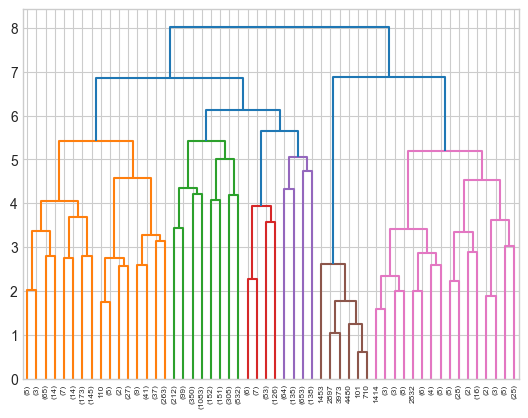

In [13]:
condensed_dist = squareform(dist_matrix)
Z = linkage(condensed_dist, method='complete')
a = dendrogram(
    Z,
    truncate_mode='level',
    p=5                
)

In [14]:
model_hier = AgglomerativeClustering(metric='precomputed', n_clusters=4, linkage='complete')
labels_hier = model_hier.fit_predict(dist_matrix)
df = df.with_columns(labels_hier=labels_hier)
print(np.unique(labels_hier, return_counts=True))

(array([0, 1, 2, 3]), array([4066,  811,    6,  117]))


In [15]:
create_chemiscope_viewer(df, dist_matrix, labels_hier, 'PCA')

2026-05-07 08:52:51.651 | INFO     | src.helper_functions:create_chemiscope_viewer:1139 - Running PCA dimensionality reduction...
2026-05-07 08:52:51.653 | INFO     | src.helper_functions:create_chemiscope_viewer:1148 - Converting structures/molecules to ASE Atoms for Chemiscope...
2026-05-07 08:54:08.987 | INFO     | src.helper_functions:create_chemiscope_viewer:1216 - Assembling properties for Chemiscope...
2026-05-07 08:54:08.996 | INFO     | src.helper_functions:create_chemiscope_viewer:1311 - Generating Chemiscope widget...
2026-05-07 08:54:09.332 | SUCCESS  | src.helper_functions:create_chemiscope_viewer:1342 - Saved Chemiscope input to: qm9_PCA_clustering.json
2026-05-07 08:54:09.429 | WARNING  | src.helper_functions:create_chemiscope_viewer:1348 - If the viewer does not open automatically, run `chemiscope show qm9_PCA_clustering.json`.


<ChemiscopeWidget(meta={'name': 'QM9 - PCA Clustering'}, settings={'map': {'x': {'property': 'PCA_1'}, 'y': {'…

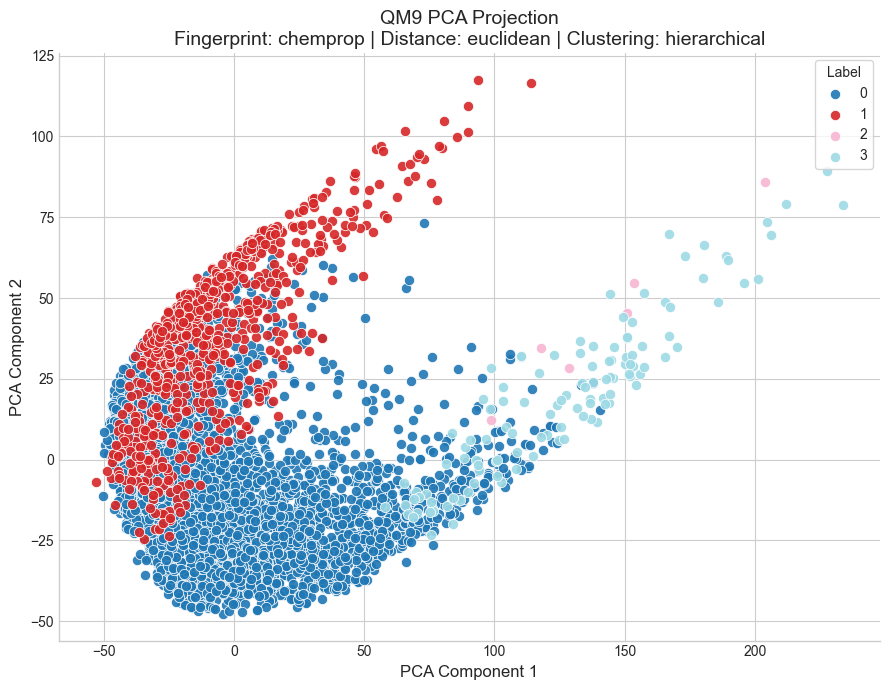

2026-05-07 08:54:10.287 | SUCCESS  | src.helper_functions:plot_distance_matrix_projection:604 - Saved PCA projection plot to figures/qm9/clustering/euclidean/chemprop/pca_hierarchical_projection.png


{'coords': array([[  9.63978177,  34.66804428],
        [-24.99344978,  25.77170807],
        [-40.91779862,   7.31230906],
        ...,
        [ -6.24930283,  44.45131065],
        [-26.43996051,  33.63076943],
        [-16.52978194,  35.5852359 ]], shape=(5000, 2)),
 'figure_path': PosixPath('figures/qm9/clustering/euclidean/chemprop/pca_hierarchical_projection.png'),
 'output_dir': PosixPath('figures/qm9/clustering/euclidean/chemprop'),
 'clustering_method': 'hierarchical'}

In [16]:
plot_distance_matrix_projection(
    dist_matrix=dist_matrix,
    fingerprint="chemprop",
    distance_metric="euclidean",
    projection_method="PCA",
    dataset_name="qm9",
    labels=labels_hier,
    clustering_method="hierarchical"
)

In [17]:
average_numeric_by_cluster(df, "labels_hier")

shape: (4, 71)
┌─────────────┬───────┬─────────────────┬─────────────┬────────────┬─────────┬─────────┬─────────────────┬─────────────────┬─────────────────┬───────────┬─────────────────┬──────────────┬─────────────────┬───────────┬──────────────┬─────────────────┬───────────────┬───────────────┬───────────────┬───────────────┬─────────────────┬─────────────────┬────────────────┬─────────────────┬─────────────────┬─────────────────┬─────────────────┬────────────────┬────────────┬────────────┬───────────┬──────────┬──────────┬────────────────┬──────────┬───────────┬──────────┬──────────┬────────┬─────────┬─────────┬─────────┬────────┬───────────┬────────┬─────────────┬─────────────┬─────────────┬─────────────┬─────────┬──────────┬──────────┬──────────┬──────────┬────────┬────────┬────────┬────────────────┬──────────────┬─────────────┬────────────────┬────────────────┬────────────────┬────────────────┬────────────────┬────────────────┬────────────────┬────────────────┬────────────────┬──

labels_hier,count,token_to_atom_ratio,is_injected,mol_weight,logp,tpsa,election_affinity,ionization_energies,num_heavy_atoms,num_rings,num_aromatic_rings,num_fluorine,num_heteroatoms,num_atoms,coordination,num_rotatable_bonds,fraction_csp1,fraction_csp2,fraction_csp3,h_bond_donors,h_bond_acceptors,branching_index,num_sp_carbons,num_sp2_carbons,num_sp3_carbons,main_chain_length,raw_token_count,avg_bond_length,fr_benzene,fr_alcohol,fr_phenol,fr_amine,fr_amide,fr_carboxylic_acid,fr_ester,fr_ketone,fr_ether,fr_nitro,mu,alpha,homo,lumo,gap,r2,zpve,u0,u,h,g,cv,u0_atom,u_atom,h_atom,g_atom,A,B,C,pct_aliphatic_ring,pct_aromatic,pct_acyclic,avg_len_selfies,unique_scaffolds,top_scaffold,top_scaffold_pct,unique_generic_scaffolds,top_generic_scaffold,top_generic_scaffold_pct,unique_outlier_categories,top_outlier_category,top_outlier_category_pct
i64,u32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,u32,str,f64,u32,str,f64,u32,str,f64
0,4066,0.740438,0.0,123.220856,0.120758,33.589277,0.885114,12.845691,8.78972,1.737826,0.106001,0.013773,2.295868,18.994343,2.069571,2.415642,0.040522,0.186785,0.772694,0.890802,1.892277,6.775947,0.279636,1.128628,5.085588,6.354894,13.837924,1.262471,0.003197,0.369897,0.017954,0.106247,0.135268,0.00123,0.036891,0.128136,0.588047,0.0,2.566806,75.969498,-6.501325,0.494856,6.996203,1195.013523,4.267957,-11130.120988,-11129.887251,-11129.861557,-11131.032796,32.142831,-78.278249,-78.765043,-79.219856,-72.81211,3.307431,1.402705,1.127224,79.808165,10.600098,9.591736,13.837924,1314,"""Acyclic""",9.591736,296,"""C1CCCC1""",10.034432,1,null,0.0
1,811,0.846654,0.0,120.435265,0.002466,52.45746,0.724462,12.899245,8.725031,0.938348,0.568434,0.075216,3.313194,14.840937,1.993446,1.808878,0.196422,0.478635,0.324944,0.963009,2.784217,4.956843,1.218249,2.293465,1.900123,6.464858,12.323058,1.260894,0.007398,0.23058,0.104809,0.244143,0.08508,0.002466,0.036991,0.08508,0.261406,0.006165,3.35204,71.48651,-6.664078,-0.722598,5.941477,1198.355766,3.033886,-11463.863435,-11463.639783,-11463.614117,-11464.772351,29.595108,-65.449282,-65.79517,-66.149221,-61.109605,4.147055,1.351474,1.012853,30.826141,52.15783,17.01603,12.323058,227,"""Acyclic""",17.01603,23,"""C1CCCC1""",27.990136,1,null,0.0
2,6,0.946693,0.0,119.666667,0.0,30.666667,1.053708,12.730961,8.5,4.0,0.0,0.0,2.5,16.166667,2.273134,1.5,0.0,0.0,1.0,0.333333,2.5,6.0,0.0,0.0,6.0,5.833333,15.166667,1.287067,0.0,0.333333,0.0,0.0,0.0,0.0,0.0,0.0,2.166667,0.0,1.756133,65.829998,-6.741621,1.463066,8.20514,989.232707,3.468118,-11457.390299,-11457.188639,-11457.16276,-11458.255046,28.5115,-67.316423,-67.737415,-68.127208,-62.566218,3.719015,1.797518,1.406565,100.0,0.0,0.0,15.166667,5,"""O1C2C3OC2C13""",33.333333,5,"""C1C2C3CC2C13""",33.333333,1,null,0.0
3,117,0.931272,0.0,120.632479,-1.376068,20.940171,0.806824,12.796383,8.820513,4.196581,0.0,0.0,1.974359,18.444444,2.298395,0.957265,0.036528,0.04475,0.918722,1.538462,0.777778,7.846154,0.264957,0.299145,6.282051,5.752137,17.008547,1.281171,0.0,0.282051,0.0,0.188034,0.008547,0.008547,0.0,0.068376,0.179487,0.0,2.318454,73.329573,-6.183939,0.807969,6.992117,916.936532,3.760249,-10504.667869,-10504.485861,-10504.460145,-10505.507312,27.282812,-72.351061,-72.823246,-73.233805,-67.310525,3.629974,1.854795,1.603228,100.0,0.0,0.0,17.008547,78,"""C12C3C1[NH+]1C2C31""",6.837607,47,"""C1C2C3C1C1C2C31""",11.965812,1,null,0.0


# KMedoids

In [18]:
model_km = KMedoids(n_clusters=3, metric="precomputed")
labels_km = model_km.fit_predict(dist_matrix)
df = df.with_columns(labels_km=labels_km)

In [19]:
create_chemiscope_viewer(df, dist_matrix, labels_km, 'PCA')

2026-05-07 08:54:11.292 | INFO     | src.helper_functions:create_chemiscope_viewer:1139 - Running PCA dimensionality reduction...
2026-05-07 08:54:11.293 | INFO     | src.helper_functions:create_chemiscope_viewer:1148 - Converting structures/molecules to ASE Atoms for Chemiscope...
2026-05-07 08:55:21.310 | INFO     | src.helper_functions:create_chemiscope_viewer:1216 - Assembling properties for Chemiscope...
2026-05-07 08:55:21.317 | INFO     | src.helper_functions:create_chemiscope_viewer:1311 - Generating Chemiscope widget...
2026-05-07 08:55:21.603 | SUCCESS  | src.helper_functions:create_chemiscope_viewer:1342 - Saved Chemiscope input to: qm9_PCA_clustering.json
2026-05-07 08:55:21.687 | WARNING  | src.helper_functions:create_chemiscope_viewer:1348 - If the viewer does not open automatically, run `chemiscope show qm9_PCA_clustering.json`.


<ChemiscopeWidget(meta={'name': 'QM9 - PCA Clustering'}, settings={'map': {'x': {'property': 'PCA_1'}, 'y': {'…

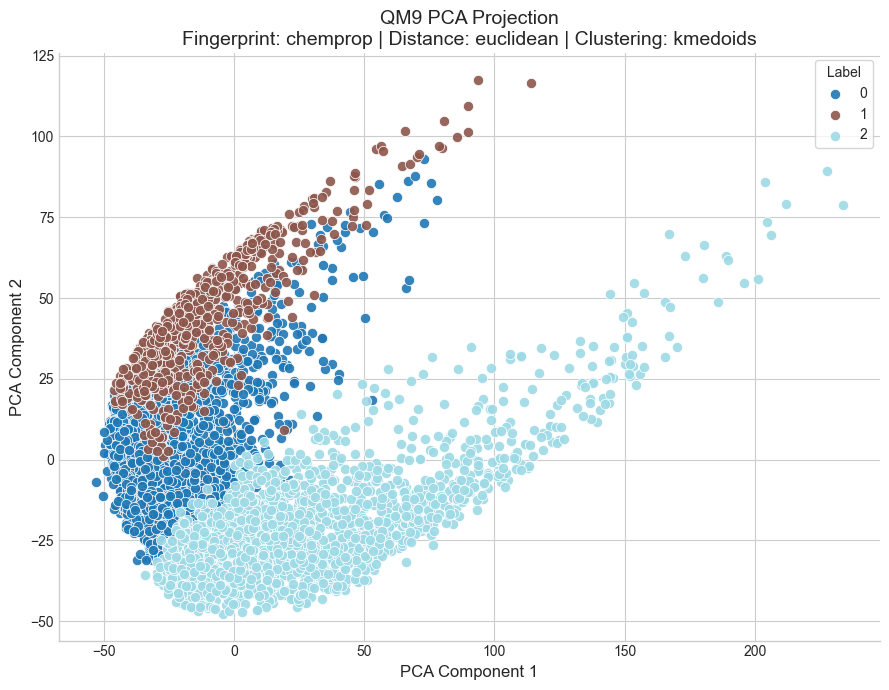

2026-05-07 08:55:22.483 | SUCCESS  | src.helper_functions:plot_distance_matrix_projection:604 - Saved PCA projection plot to figures/qm9/clustering/euclidean/chemprop/pca_kmedoids_projection.png


{'coords': array([[  9.63978177,  34.66804428],
        [-24.99344978,  25.77170807],
        [-40.91779862,   7.31230906],
        ...,
        [ -6.24930283,  44.45131065],
        [-26.43996051,  33.63076943],
        [-16.52978194,  35.5852359 ]], shape=(5000, 2)),
 'figure_path': PosixPath('figures/qm9/clustering/euclidean/chemprop/pca_kmedoids_projection.png'),
 'output_dir': PosixPath('figures/qm9/clustering/euclidean/chemprop'),
 'clustering_method': 'kmedoids'}

In [20]:
plot_distance_matrix_projection(
    dist_matrix=dist_matrix,
    fingerprint="chemprop",
    distance_metric="euclidean",
    projection_method="PCA",
    dataset_name="qm9",
    labels=labels_km,
    clustering_method="kmedoids"
)

In [21]:
average_numeric_by_cluster(df, "labels_km")

shape: (3, 72)
┌───────────┬───────┬─────────────────┬─────────────┬────────────┬─────────┬─────────┬─────────────────┬─────────────────┬────────────────┬───────────┬────────────────┬──────────────┬────────────────┬───────────┬──────────────┬────────────────┬───────────────┬───────────────┬───────────────┬───────────────┬────────────────┬────────────────┬────────────────┬────────────────┬────────────────┬────────────────┬────────────────┬────────────────┬────────────┬────────────┬───────────┬──────────┬──────────┬────────────────┬──────────┬───────────┬──────────┬──────────┬────────┬─────────┬─────────┬─────────┬────────┬───────────┬────────┬─────────────┬─────────────┬─────────────┬─────────────┬─────────┬──────────┬──────────┬──────────┬──────────┬────────┬────────┬────────┬─────────────┬────────────────┬──────────────┬─────────────┬────────────────┬────────────────┬──────────────┬────────────────┬────────────────┬────────────────┬────────────────┬────────────────┬────────────────┬──

labels_km,count,token_to_atom_ratio,is_injected,mol_weight,logp,tpsa,election_affinity,ionization_energies,num_heavy_atoms,num_rings,num_aromatic_rings,num_fluorine,num_heteroatoms,num_atoms,coordination,num_rotatable_bonds,fraction_csp1,fraction_csp2,fraction_csp3,h_bond_donors,h_bond_acceptors,branching_index,num_sp_carbons,num_sp2_carbons,num_sp3_carbons,main_chain_length,raw_token_count,avg_bond_length,fr_benzene,fr_alcohol,fr_phenol,fr_amine,fr_amide,fr_carboxylic_acid,fr_ester,fr_ketone,fr_ether,fr_nitro,mu,alpha,homo,lumo,gap,r2,zpve,u0,u,h,g,cv,u0_atom,u_atom,h_atom,g_atom,A,B,C,labels_hier,pct_aliphatic_ring,pct_aromatic,pct_acyclic,avg_len_selfies,unique_scaffolds,top_scaffold,top_scaffold_pct,unique_generic_scaffolds,top_generic_scaffold,top_generic_scaffold_pct,unique_outlier_categories,top_outlier_category,top_outlier_category_pct
u64,u32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,u32,str,f64,u32,str,f64,u32,str,f64
0,2091,0.697434,0.0,122.800574,0.16021,37.656624,0.88913,12.848483,8.735055,0.989,0.072214,0.008608,2.446198,18.588714,1.997895,2.835485,0.101973,0.200628,0.697398,0.823051,2.063606,6.092779,0.681014,1.243424,4.364419,6.628407,12.721186,1.25373,0.005739,0.393113,0.006695,0.117647,0.184122,0.000956,0.056911,0.167384,0.599235,0.0,2.837961,75.597398,-6.702793,0.080661,6.783446,1298.077289,4.146112,-11217.568979,-11217.322535,-11217.29683,-11218.504762,32.853359,-77.069062,-77.529532,-77.975273,-71.733306,3.506639,1.267869,1.011251,0.164993,70.444763,7.221425,22.333812,12.721186,489,"""Acyclic""",22.333812,100,"""Acyclic""",22.333812,1,null,0.0
1,826,0.854707,0.0,121.708232,0.014528,56.460048,0.651333,13.018719,8.72276,1.075061,0.883777,0.116223,3.837772,14.903148,2.010774,1.975787,0.057803,0.681053,0.261144,1.175545,3.072639,5.675545,0.309927,3.284504,1.290557,6.365617,12.527845,1.258303,0.008475,0.104116,0.174334,0.337772,0.122276,0.003632,0.03753,0.039952,0.236077,0.006053,3.25719,70.354177,-6.236879,-0.607354,5.629548,1133.023036,3.068364,-11745.524752,-11745.309026,-11745.283374,-11746.421438,28.774665,-64.948707,-65.30346,-65.658146,-60.58313,4.177877,1.445236,1.04162,0.564165,8.837772,83.77724,7.384988,12.527845,258,"""Acyclic""",7.384988,27,"""C1CCCC1""",45.399516,1,null,0.0
2,2083,0.790961,0.0,123.0024,-0.007201,27.06433,0.907327,12.792025,8.846855,2.585694,0.005281,0.00144,1.912146,19.367739,2.148637,1.847816,0.032339,0.082003,0.885659,0.908785,1.538646,7.24772,0.228517,0.56217,6.144023,6.083533,15.070571,1.273407,0.0,0.392703,0.0,0.06097,0.06433,0.00144,0.014402,0.103217,0.570811,0.0,2.310281,76.646841,-6.450179,0.894087,7.344319,1101.22508,4.354663,-10894.054482,-10893.833283,-10893.807593,-10894.942893,31.489819,-79.418465,-79.928171,-80.389893,-73.849566,3.108493,1.527777,1.260599,0.174268,99.471916,0.528084,0.0,15.070571,889,"""C1CC2CC12""",3.600576,272,"""C1CC2CC12""",12.770043,1,null,0.0


# Spectral

In [22]:
kernel = np.exp(-dist_matrix**2 / (2 * np.std(dist_matrix)**2))
model_spectral = SpectralClustering(
                n_clusters=3,
                affinity="precomputed",
                assign_labels='kmeans',
                random_state=42,
            )

labels_spectral = model_spectral.fit_predict(kernel)
df = df.with_columns(labels_spectral=labels_spectral)

In [23]:
create_chemiscope_viewer(df, dist_matrix, labels_spectral, 'PCA')

2026-05-07 08:55:25.146 | INFO     | src.helper_functions:create_chemiscope_viewer:1139 - Running PCA dimensionality reduction...
2026-05-07 08:55:25.147 | INFO     | src.helper_functions:create_chemiscope_viewer:1148 - Converting structures/molecules to ASE Atoms for Chemiscope...
2026-05-07 08:56:29.375 | INFO     | src.helper_functions:create_chemiscope_viewer:1216 - Assembling properties for Chemiscope...
2026-05-07 08:56:29.415 | INFO     | src.helper_functions:create_chemiscope_viewer:1311 - Generating Chemiscope widget...
2026-05-07 08:56:29.835 | SUCCESS  | src.helper_functions:create_chemiscope_viewer:1342 - Saved Chemiscope input to: qm9_PCA_clustering.json
2026-05-07 08:56:29.970 | WARNING  | src.helper_functions:create_chemiscope_viewer:1348 - If the viewer does not open automatically, run `chemiscope show qm9_PCA_clustering.json`.


<ChemiscopeWidget(meta={'name': 'QM9 - PCA Clustering'}, settings={'map': {'x': {'property': 'PCA_1'}, 'y': {'…

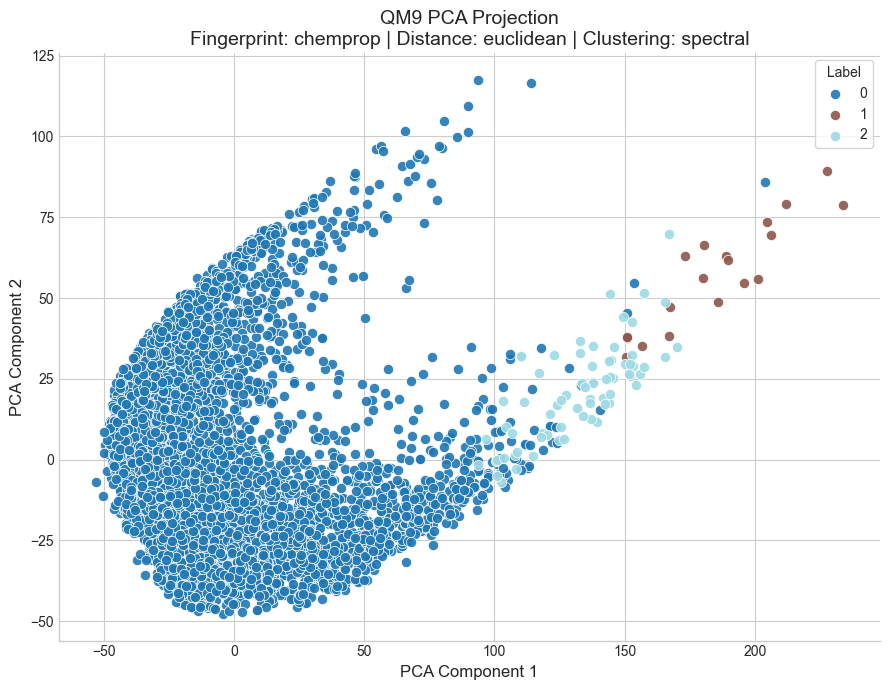

2026-05-07 08:56:31.257 | SUCCESS  | src.helper_functions:plot_distance_matrix_projection:604 - Saved PCA projection plot to figures/qm9/clustering/euclidean/chemprop/pca_spectral_projection.png


{'coords': array([[  9.63978177,  34.66804428],
        [-24.99344978,  25.77170807],
        [-40.91779862,   7.31230906],
        ...,
        [ -6.24930283,  44.45131065],
        [-26.43996051,  33.63076943],
        [-16.52978194,  35.5852359 ]], shape=(5000, 2)),
 'figure_path': PosixPath('figures/qm9/clustering/euclidean/chemprop/pca_spectral_projection.png'),
 'output_dir': PosixPath('figures/qm9/clustering/euclidean/chemprop'),
 'clustering_method': 'spectral'}

In [24]:
plot_distance_matrix_projection(
    dist_matrix=dist_matrix,
    fingerprint="chemprop",
    distance_metric="euclidean",
    projection_method="PCA",
    dataset_name="qm9",
    labels=labels_spectral,
    clustering_method="spectral"
)

In [25]:
average_numeric_by_cluster(df, "labels_spectral")

shape: (3, 73)
┌────────────────┬───────┬────────────────┬─────────────┬────────────┬─────────┬─────────┬────────────────┬────────────────┬────────────────┬───────────┬────────────────┬──────────────┬────────────────┬───────────┬──────────────┬────────────────┬───────────────┬───────────────┬───────────────┬───────────────┬────────────────┬────────────────┬────────────────┬────────────────┬────────────────┬───────────────┬───────────────┬───────────────┬────────────┬────────────┬───────────┬──────────┬──────────┬───────────────┬──────────┬───────────┬──────────┬──────────┬────────┬─────────┬─────────┬────────┬────────┬───────────┬────────┬─────────────┬─────────────┬─────────────┬─────────────┬─────────┬──────────┬──────────┬──────────┬──────────┬────────┬────────┬────────┬─────────────┬───────────┬───────────────┬──────────────┬─────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬─

labels_spectral,count,token_to_atom_ratio,is_injected,mol_weight,logp,tpsa,election_affinity,ionization_energies,num_heavy_atoms,num_rings,num_aromatic_rings,num_fluorine,num_heteroatoms,num_atoms,coordination,num_rotatable_bonds,fraction_csp1,fraction_csp2,fraction_csp3,h_bond_donors,h_bond_acceptors,branching_index,num_sp_carbons,num_sp2_carbons,num_sp3_carbons,main_chain_length,raw_token_count,avg_bond_length,fr_benzene,fr_alcohol,fr_phenol,fr_amine,fr_amide,fr_carboxylic_acid,fr_ester,fr_ketone,fr_ether,fr_nitro,mu,alpha,homo,lumo,gap,r2,zpve,u0,u,h,g,cv,u0_atom,u_atom,h_atom,g_atom,A,B,C,labels_hier,labels_km,pct_aliphatic_ring,pct_aromatic,pct_acyclic,avg_len_selfies,unique_scaffolds,top_scaffold,top_scaffold_pct,unique_generic_scaffolds,top_generic_scaffold,top_generic_scaffold_pct,unique_outlier_categories,top_outlier_category,top_outlier_category_pct
i32,u32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,u32,str,f64,u32,str,f64,u32,str,f64
0,4911,0.759091,0.0,122.759927,0.092853,36.649155,0.858285,12.854202,8.780086,1.620037,0.181633,0.023824,2.463449,18.302993,2.058288,2.304622,0.066352,0.23408,0.699568,0.904704,2.035023,6.479332,0.435349,1.315822,4.565465,6.370393,13.605172,1.262352,0.003869,0.345551,0.032173,0.129098,0.126044,0.001629,0.036652,0.120138,0.534922,0.001018,2.697247,75.211989,-6.526956,0.29688,6.823858,1194.20759,4.060871,-11184.228024,-11183.996263,-11183.970573,-11185.138948,31.692872,-76.123341,-76.586762,-77.02466,-70.845813,3.448711,1.395626,1.109935,0.187131,0.980248,71.859092,17.389534,10.751374,13.605172,1478,"""Acyclic""",10.751374,307,"""C1CCCC1""",12.930157,1,null,0.0
1,19,1.00172,0.0,118.842105,-2.157895,26.578947,0.771352,12.814435,8.684211,4.263158,0.0,0.0,2.263158,17.526316,2.352501,0.842105,0.037594,0.02381,0.938596,2.0,0.947368,7.736842,0.263158,0.157895,6.0,5.578947,17.210526,1.281884,0.0,0.421053,0.0,0.368421,0.0,0.0,0.0,0.157895,0.052632,0.0,2.5071,69.91579,-6.087617,0.25149,6.33925,849.01133,3.327845,-10486.674728,-10486.500925,-10486.475098,-10487.503289,26.023631,-66.552065,-66.9787,-67.353377,-61.915839,3.862544,2.044952,1.821062,3.0,2.0,100.0,0.0,0.0,17.210526,14,"""C12C3C1[NH+]1C2C31""",21.052632,12,"""C12C3C1C1C2C31""",21.052632,1,null,0.0
2,70,0.928078,0.0,119.842857,-1.185714,18.028571,0.820557,12.785296,8.771429,4.357143,0.0,0.0,1.814286,18.614286,2.302258,1.085714,0.02517,0.040816,0.934014,1.485714,0.657143,7.971429,0.185714,0.271429,6.5,5.7,17.114286,1.28066,0.0,0.3,0.0,0.157143,0.014286,0.0,0.0,0.071429,0.128571,0.0,2.044496,73.537143,-6.191134,0.951621,7.142833,901.768438,3.836941,-10358.071729,-10357.889146,-10357.863456,-10358.909626,27.419929,-73.164079,-73.644399,-74.060762,-68.063831,3.547022,1.920917,1.646332,2.828571,2.0,100.0,0.0,0.0,17.114286,48,"""C1C2C3C[NH+]2C13""",10.0,28,"""C1C2C3C1C1C2C31""",17.142857,1,null,0.0


# DBSCAN 

In [26]:
model_db = DBSCAN(
    eps=0.08,
    min_samples=2,
    metric='precomputed',
)

labels_db = model_db.fit_predict(dist_matrix)
df = df.with_columns(labels_db=labels_db)
print(np.unique(labels_db, return_counts=True))

(array([-1,  0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15,
       16, 17, 18, 19, 20, 21, 22, 23]), array([4952,    2,    2,    2,    2,    2,    2,    2,    2,    2,    2,
          2,    2,    2,    2,    2,    2,    2,    2,    2,    2,    2,
          2,    2,    2]))


In [27]:
create_chemiscope_viewer(df, dist_matrix, labels_db, 'PCA')

2026-05-07 08:56:32.210 | INFO     | src.helper_functions:create_chemiscope_viewer:1139 - Running PCA dimensionality reduction...
2026-05-07 08:56:32.214 | INFO     | src.helper_functions:create_chemiscope_viewer:1148 - Converting structures/molecules to ASE Atoms for Chemiscope...
2026-05-07 08:57:53.613 | INFO     | src.helper_functions:create_chemiscope_viewer:1216 - Assembling properties for Chemiscope...
2026-05-07 08:57:53.620 | INFO     | src.helper_functions:create_chemiscope_viewer:1311 - Generating Chemiscope widget...
2026-05-07 08:57:53.908 | SUCCESS  | src.helper_functions:create_chemiscope_viewer:1342 - Saved Chemiscope input to: qm9_PCA_clustering.json
2026-05-07 08:57:53.990 | WARNING  | src.helper_functions:create_chemiscope_viewer:1348 - If the viewer does not open automatically, run `chemiscope show qm9_PCA_clustering.json`.


<ChemiscopeWidget(meta={'name': 'QM9 - PCA Clustering'}, settings={'map': {'x': {'property': 'PCA_1'}, 'y': {'…

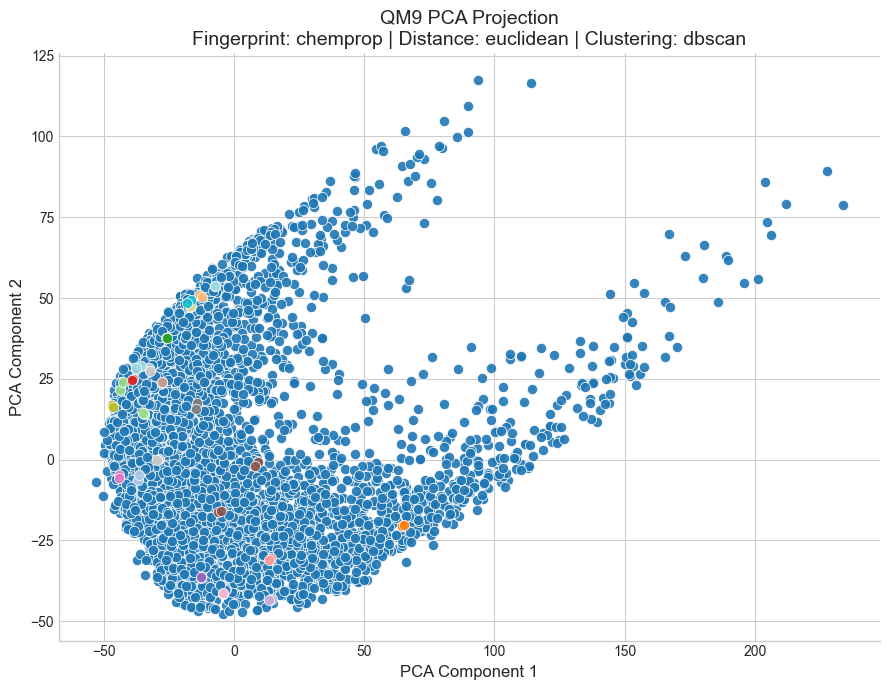

2026-05-07 08:57:54.728 | SUCCESS  | src.helper_functions:plot_distance_matrix_projection:604 - Saved PCA projection plot to figures/qm9/clustering/euclidean/chemprop/pca_dbscan_projection.png


{'coords': array([[  9.63978177,  34.66804428],
        [-24.99344978,  25.77170807],
        [-40.91779862,   7.31230906],
        ...,
        [ -6.24930283,  44.45131065],
        [-26.43996051,  33.63076943],
        [-16.52978194,  35.5852359 ]], shape=(5000, 2)),
 'figure_path': PosixPath('figures/qm9/clustering/euclidean/chemprop/pca_dbscan_projection.png'),
 'output_dir': PosixPath('figures/qm9/clustering/euclidean/chemprop'),
 'clustering_method': 'dbscan'}

In [28]:
plot_distance_matrix_projection(
    dist_matrix=dist_matrix,
    fingerprint="chemprop",
    distance_metric="euclidean",
    projection_method="PCA",
    dataset_name="qm9",
    labels=labels_db,
    clustering_method="dbscan"
)

In [29]:
average_numeric_by_cluster(df, "labels_db")

shape: (25, 74)
┌───────────┬───────┬───────────────┬─────────────┬────────────┬─────────┬─────────┬───────────────┬───────────────┬───────────────┬───────────┬───────────────┬──────────────┬───────────────┬───────────┬──────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬────────────┬────────────┬───────────┬──────────┬──────────┬───────────────┬──────────┬───────────┬──────────┬──────────┬────────┬─────────┬─────────┬─────────┬────────┬───────────┬────────┬─────────────┬─────────────┬─────────────┬─────────────┬─────────┬───────────┬───────────┬───────────┬──────────┬────────┬────────┬────────┬─────────────┬───────────┬───────────────┬───────────────┬──────────────┬─────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬──────────────┬──────────────

labels_db,count,token_to_atom_ratio,is_injected,mol_weight,logp,tpsa,election_affinity,ionization_energies,num_heavy_atoms,num_rings,num_aromatic_rings,num_fluorine,num_heteroatoms,num_atoms,coordination,num_rotatable_bonds,fraction_csp1,fraction_csp2,fraction_csp3,h_bond_donors,h_bond_acceptors,branching_index,num_sp_carbons,num_sp2_carbons,num_sp3_carbons,main_chain_length,raw_token_count,avg_bond_length,fr_benzene,fr_alcohol,fr_phenol,fr_amine,fr_amide,fr_carboxylic_acid,fr_ester,fr_ketone,fr_ether,fr_nitro,mu,alpha,homo,lumo,gap,r2,zpve,u0,u,h,g,cv,u0_atom,u_atom,h_atom,g_atom,A,B,C,labels_hier,labels_km,labels_spectral,pct_aliphatic_ring,pct_aromatic,pct_acyclic,avg_len_selfies,unique_scaffolds,top_scaffold,top_scaffold_pct,unique_generic_scaffolds,top_generic_scaffold,top_generic_scaffold_pct,unique_outlier_categories,top_outlier_category,top_outlier_category_pct
i64,u32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,u32,str,f64,u32,str,f64,u32,str,f64
-1,4952,0.762271,0.0,122.693255,0.063813,36.25101,0.858015,12.852666,8.778675,1.671244,0.174879,0.023223,2.450323,18.309774,2.063103,2.277464,0.066088,0.228251,0.705661,0.91458,2.006462,6.503837,0.434168,1.284733,4.609451,6.356422,13.671244,1.262736,0.003837,0.345315,0.030291,0.128433,0.125202,0.001616,0.036349,0.119144,0.530897,0.00101,2.685566,75.159105,-6.522913,0.311291,6.834226,1188.453063,4.055807,-11167.759809,-11167.528966,-11167.503276,-11168.669412,31.609403,-76.048562,-76.51219,-76.949612,-70.775362,3.452283,1.405862,1.12079,0.235057,0.999192,0.032108,72.6979,16.720517,10.581583,13.671244,1527,"""Acyclic""",10.581583,324,"""C1CCCC1""",12.540388,1,null,0.0
0,2,1.0,0.0,112.0,0.0,69.0,0.68229,12.978272,8.0,1.0,1.0,0.0,4.0,12.0,2.0,2.0,0.0,1.0,0.0,1.0,4.0,5.0,0.0,4.0,0.0,6.0,12.0,1.260659,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,5.11805,64.735003,-6.163379,-1.537443,4.625936,946.645813,2.303553,-11284.60791,-11284.421875,-11284.396484,-11285.453613,24.7145,-54.875549,-55.152317,-55.434988,-51.345999,6.0982,1.424995,1.15031,1.0,1.0,0.0,0.0,100.0,0.0,12.0,1,"""c1cocn1""",100.0,1,"""C1CCCC1""",100.0,1,null,0.0
1,2,0.666667,0.0,114.0,0.0,37.0,1.002049,12.821232,8.0,1.0,0.0,0.0,2.0,18.0,2.0,2.0,0.0,0.166667,0.833333,1.0,2.0,6.0,0.0,1.0,5.0,5.5,12.0,1.254134,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,2.28655,67.355,-6.627333,-0.738789,5.888544,945.436096,4.185111,-10475.725098,-10475.505859,-10475.47998,-10476.610352,30.2575,-75.192932,-75.6675,-76.104446,-69.99025,3.1421,1.888625,1.3409,0.0,0.0,0.0,100.0,0.0,0.0,12.0,1,"""O=C1CCCC1""",100.0,1,"""CC1CCCC1""",100.0,1,null,0.0
2,2,0.9375,0.0,112.0,0.0,40.0,1.033031,12.724082,8.0,3.0,0.0,0.0,2.0,16.0,2.25,2.0,0.0,0.0,1.0,2.0,2.0,6.0,0.0,0.0,6.0,6.0,15.0,1.289071,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.2129,63.804998,-6.402839,1.752413,8.156613,795.579285,3.552501,-10440.403809,-10440.213379,-10440.1875,-10441.240234,27.816,-67.098061,-67.52404,-67.909573,-62.426586,3.736635,2.05103,1.704755,0.0,2.0,0.0,100.0,0.0,0.0,15.0,2,"""C1C2C1C1CC21""",50.0,2,"""C1C2CC3C1C23""",50.0,1,null,0.0
3,2,1.0,0.0,126.0,-1.0,97.0,0.362317,13.225756,9.0,1.0,1.0,0.0,5.0,15.0,2.0,2.0,0.0,1.0,0.0,3.0,4.0,7.0,0.0,4.0,0.0,7.0,15.0,1.240985,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,3.1746,75.760002,-5.053154,-0.559194,4.495321,1121.159729,3.146602,-12250.592773,-12250.37793,-12250.352539,-12251.462891,30.748,-65.640362,-66.003677,-66.363449,-61.144699,3.26795,1.412685,0.988935,1.0,1.0,0.0,0.0,100.0,0.0,15.0,2,"""O=c1cncc[nH]1""",50.0,1,"""CC1CCCCC1""",100.0,1,null,0.0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
19,2,0.611111,0.0,127.0,0.0,46.0,0.882372,12.873216,9.0,1.0,1.0,0.0,3.0,18.0,2.0,4.0,0.0,0.5,0.5,1.0,3.0,6.0,0.0,3.0,3.0,7.0,11.0,1.249651,0.0,

# HDBSCAN

In [30]:
a = evaluate_hdbscan_grid(dist_matrix)


Top configurations:

mcs=220, ms=1, clusters=3, noise=0.29, persistence=0.171, score=0.121
mcs=150, ms=1, clusters=3, noise=0.29, persistence=0.169, score=0.120
mcs=120, ms=1, clusters=3, noise=0.29, persistence=0.167, score=0.119
mcs=300, ms=1, clusters=3, noise=0.29, persistence=0.154, score=0.109
mcs=80, ms=1, clusters=5, noise=0.25, persistence=0.104, score=0.078
mcs=60, ms=10, clusters=2, noise=0.49, persistence=0.090, score=0.046
mcs=80, ms=10, clusters=2, noise=0.49, persistence=0.090, score=0.046
mcs=40, ms=1, clusters=7, noise=0.30, persistence=0.065, score=0.045
mcs=60, ms=1, clusters=7, noise=0.35, persistence=0.069, score=0.045
mcs=120, ms=10, clusters=2, noise=0.49, persistence=0.084, score=0.043
mcs=150, ms=10, clusters=2, noise=0.49, persistence=0.077, score=0.039
mcs=20, ms=2, clusters=27, noise=0.41, persistence=0.062, score=0.036
mcs=40, ms=10, clusters=3, noise=0.48, persistence=0.065, score=0.034
mcs=40, ms=10, clusters=3, noise=0.48, persistence=0.065, score=0.034

In [31]:
clusterer = HDBSCAN(
        min_cluster_size=60,
        min_samples=6,
        metric='precomputed',
    )

labels_hdbscan = clusterer.fit_predict(dist_matrix.astype(np.float64))
df = df.with_columns(labels_hdbscan=labels_hdbscan)

In [ ]:
create_chemiscope_viewer(df, dist_matrix, labels_hdbscan, 'PCA')

2026-05-07 08:58:41.894 | INFO     | src.helper_functions:create_chemiscope_viewer:1139 - Running PCA dimensionality reduction...
2026-05-07 08:58:41.896 | INFO     | src.helper_functions:create_chemiscope_viewer:1148 - Converting structures/molecules to ASE Atoms for Chemiscope...


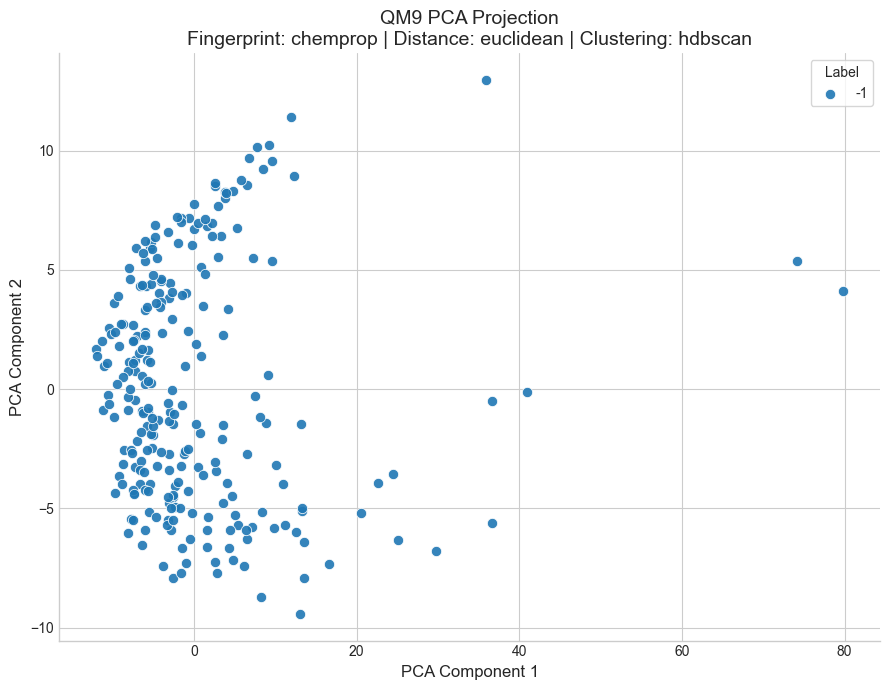

2026-04-28 21:22:55.406 | SUCCESS  | src.helper_functions:plot_distance_matrix_projection:530 - Saved PCA projection plot to figures/qm9/clustering/euclidean/chemprop/pca_hdbscan_projection.png


{'coords': array([[ 3.86213246e+00,  8.00344405e+00],
        [ 6.56393521e+00, -2.72085329e+00],
        [-5.75046272e+00,  1.22052038e+00],
        [-4.10397355e-02,  6.69995928e+00],
        [-5.90598397e+00,  4.32928532e+00],
        [ 3.53227415e+00,  2.27681139e+00],
        [ 7.52084685e+00, -2.71621023e-01],
        [-5.07868057e+00, -1.93367650e+00],
        [-1.56920449e+00, -3.20720487e+00],
        [ 6.49848901e+00,  8.57428816e+00],
        [-9.89606332e-01,  4.01043573e+00],
        [-9.19177061e+00,  1.80137970e+00],
        [-7.22656090e-01, -4.28449116e+00],
        [-2.98290805e+00,  4.44053689e+00],
        [-1.04210771e+01,  2.56055485e+00],
        [-1.12423858e+01, -8.85220743e-01],
        [ 5.37195460e+00, -5.71776471e+00],
        [-3.11781296e+00,  3.82905060e+00],
        [-2.57139183e+00, -4.50739195e+00],
        [ 1.33072270e+01, -5.10542411e+00],
        [-3.11040701e+00, -4.78913806e+00],
        [ 2.97411033e+01, -6.80645497e+00],
        [-7.03610616e+

In [ ]:
plot_distance_matrix_projection(
    dist_matrix=dist_matrix,
    fingerprint="chemprop",
    distance_metric="euclidean",
    projection_method="PCA",
    dataset_name="qm9",
    labels=labels_hdbscan,
    clustering_method="hdbscan"
)

In [ ]:
average_numeric_by_cluster(df, "labels_hdbscan")

shape: (1, 75)
┌───────────────┬───────┬───────────────┬─────────────┬────────────┬────────┬─────────┬───────────────┬───────────────┬───────────────┬───────────┬───────────────┬──────────────┬───────────────┬───────────┬──────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬──────────────┬────────────┬────────────┬───────────┬──────────┬──────────┬──────────────┬──────────┬───────────┬──────────┬──────────┬────────┬─────────┬─────────┬────────┬────────┬───────────┬────────┬─────────────┬─────────────┬─────────────┬─────────────┬─────────┬──────────┬──────────┬──────────┬──────────┬────────┬────────┬────────┬─────────────┬───────────┬──────────────┬───────────┬──────────────┬──────────────┬─────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬

labels_hdbscan,count,token_to_atom_ratio,is_injected,mol_weight,logp,tpsa,election_affinity,ionization_energies,num_heavy_atoms,num_rings,num_aromatic_rings,num_fluorine,num_heteroatoms,num_atoms,coordination,num_rotatable_bonds,fraction_csp1,fraction_csp2,fraction_csp3,h_bond_donors,h_bond_acceptors,branching_index,num_sp_carbons,num_sp2_carbons,num_sp3_carbons,main_chain_length,raw_token_count,avg_bond_length,fr_benzene,fr_alcohol,fr_phenol,fr_amine,fr_amide,fr_carboxylic_acid,fr_ester,fr_ketone,fr_ether,fr_nitro,mu,alpha,homo,lumo,gap,r2,zpve,u0,u,h,g,cv,u0_atom,u_atom,h_atom,g_atom,A,B,C,labels_hier,labels_km,labels_spectral,labels_db,pct_aliphatic_ring,pct_aromatic,pct_acyclic,avg_len_selfies,unique_scaffolds,top_scaffold,top_scaffold_pct,unique_generic_scaffolds,top_generic_scaffold,top_generic_scaffold_pct,unique_outlier_categories,top_outlier_category,top_outlier_category_pct
i64,u32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,u32,str,f64,u32,str,f64,u32,str,f64
-1,250,2.040372,0.0,123.5,0.112,37.956,0.863266,12.844499,8.84,1.636,0.168,0.016,2.48,18.308,2.058225,2.392,0.072829,0.228006,0.699165,0.904,2.08,6.436,0.476,1.28,4.604,6.42,37.712,1.263018,0.0,0.34,0.044,0.116,0.124,0.0,0.04,0.144,0.528,0.0,2.77938,75.51916,-6.554635,0.311298,6.866031,1225.838544,4.081386,-11267.787621,-11267.553023,-11267.527311,-11268.703895,32.050912,-76.559197,-77.023823,-77.46446,-71.249573,3.325358,1.348579,1.082357,0.06,0.716,0.012,-1.0,73.6,16.4,10.0,37.712,159,"""Acyclic""",10.0,78,"""C1CCCC1""",14.0,1,null,0.0


# KMeans on Raw Embeddings


In [ ]:
from sklearn.cluster import KMeans
import numpy as np
from sklearn.decomposition import PCA

X = np.array(df['chemprop_embedding'].to_list())
pca = PCA(n_components=4)
X = pca.fit_transform(X)

kmeans = KMeans(n_clusters=3)
labels_kmeans = kmeans.fit_predict(X)
df = df.with_columns(labels_kmeans=labels_kmeans)
print(np.unique(labels_kmeans, return_counts=True))

(array([0, 1, 2], dtype=int32), array([ 21, 119, 110]))


In [ ]:
average_numeric_by_cluster(df, 'labels_kmeans')

shape: (3, 76)
┌───────────────┬───────┬───────────────┬─────────────┬────────────┬─────────┬─────────┬──────────────┬──────────────┬──────────────┬───────────┬──────────────┬──────────────┬──────────────┬───────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬────────────┬────────────┬───────────┬──────────┬──────────┬──────────────┬──────────┬───────────┬──────────┬──────────┬────────┬─────────┬─────────┬─────────┬────────┬───────────┬────────┬─────────────┬─────────────┬─────────────┬─────────────┬─────────┬──────────┬──────────┬──────────┬──────────┬────────┬────────┬────────┬─────────────┬───────────┬──────────────┬───────────┬──────────────┬──────────────┬──────────────┬─────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬

labels_kmeans,count,token_to_atom_ratio,is_injected,mol_weight,logp,tpsa,election_affinity,ionization_energies,num_heavy_atoms,num_rings,num_aromatic_rings,num_fluorine,num_heteroatoms,num_atoms,coordination,num_rotatable_bonds,fraction_csp1,fraction_csp2,fraction_csp3,h_bond_donors,h_bond_acceptors,branching_index,num_sp_carbons,num_sp2_carbons,num_sp3_carbons,main_chain_length,raw_token_count,avg_bond_length,fr_benzene,fr_alcohol,fr_phenol,fr_amine,fr_amide,fr_carboxylic_acid,fr_ester,fr_ketone,…,mu,alpha,homo,lumo,gap,r2,zpve,u0,u,h,g,cv,u0_atom,u_atom,h_atom,g_atom,A,B,C,labels_hier,labels_km,labels_spectral,labels_db,labels_hdbscan,pct_aliphatic_ring,pct_aromatic,pct_acyclic,avg_len_selfies,unique_scaffolds,top_scaffold,top_scaffold_pct,unique_generic_scaffolds,top_generic_scaffold,top_generic_scaffold_pct,unique_outlier_categories,top_outlier_category,top_outlier_category_pct
i32,u32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,u32,str,f64,u32,str,f64,u32,str,f64
0,21,2.211443,0.0,121.714286,-0.714286,29.714286,0.865211,12.767729,8.857143,3.857143,0.0,0.0,2.047619,18.095238,2.260531,1.380952,0.035431,0.022676,0.941893,1.428571,1.47619,7.333333,0.238095,0.142857,6.428571,5.809524,40.047619,1.282719,0.0,0.666667,0.0,0.0,0.047619,0.0,0.0,0.095238,…,2.72549,73.668571,-6.369408,1.254574,7.623982,984.620765,3.922852,-10831.232608,-10831.032552,-10831.006882,-10832.090634,29.343381,-74.545656,-75.022878,-75.448789,-69.346863,3.357952,1.630992,1.408695,0.714286,1.0,0.0,-1.0,-1.0,100.0,0.0,0.0,40.047619,19,"""C1C2C3C1C1C2C31""",9.52381,16,"""C1C2C3CC2C13""",14.285714,1,null,0.0
1,119,2.129529,0.0,124.134454,0.260504,29.991597,0.932865,12.798055,8.87395,2.0,0.016807,0.0,2.016807,19.462185,2.093334,2.226891,0.033063,0.121852,0.845085,0.731092,1.831933,6.957983,0.235294,0.815126,5.806723,6.226891,41.588235,1.268996,0.0,0.394958,0.0,0.008403,0.07563,0.0,0.042017,0.184874,…,2.486071,77.016639,-6.587533,0.657166,7.244814,1189.563296,4.465568,-11124.119411,-11123.885578,-11123.859814,-11125.028722,32.608328,-80.878789,-81.391059,-81.862997,-75.211883,3.038934,1.387496,1.154573,0.0,0.680672,0.02521,-1.0,-1.0,98.319328,1.680672,0.0,41.588235,91,"""C1CC1""",10.92437,56,"""C1CC1""",17.647059,1,null,0.0
2,110,1.911262,0.0,123.154545,0.109091,48.145455,0.787601,12.9094,8.8,0.818182,0.363636,0.036364,3.063636,17.1,1.981621,2.763636,0.122987,0.382045,0.494968,0.990909,2.463636,5.7,0.781818,2.0,2.954545,6.745455,33.072727,1.25279,0.0,0.218182,0.1,0.254545,0.190909,0.0,0.045455,0.109091,…,3.106974,74.252454,-6.554406,-0.242948,6.311557,1311.132434,3.696037,-11506.552823,-11506.310804,-11506.285138,-11507.487749,31.964782,-72.270586,-72.681267,-73.090851,-67.326318,3.628993,1.252562,0.941932,0.0,0.7,0.0,-1.0,-1.0,41.818182,35.454545,22.727273,33.072727,57,"""Acyclic""",22.727273,13,"""C1CCCC1""",30.0,1,null,0.0


In [ ]:
create_chemiscope_viewer(df, X, labels_kmeans, 'PCA')

2026-04-28 21:22:55.592 | INFO     | src.helper_functions:create_chemiscope_viewer:1065 - Running PCA dimensionality reduction...
2026-04-28 21:22:55.637 | INFO     | src.helper_functions:create_chemiscope_viewer:1074 - Converting structures/molecules to ASE Atoms for Chemiscope...
2026-04-28 21:22:56.415 | INFO     | src.helper_functions:create_chemiscope_viewer:1142 - Assembling properties for Chemiscope...
2026-04-28 21:22:56.417 | INFO     | src.helper_functions:create_chemiscope_viewer:1237 - Generating Chemiscope widget...
2026-04-28 21:22:56.430 | SUCCESS  | src.helper_functions:create_chemiscope_viewer:1268 - Saved Chemiscope input to: qm9_PCA_clustering.json
2026-04-28 21:22:56.434 | WARNING  | src.helper_functions:create_chemiscope_viewer:1274 - If the viewer does not open automatically, run `chemiscope show qm9_PCA_clustering.json`.


<ChemiscopeWidget(meta={'name': 'QM9 - PCA Clustering'}, settings={'map': {'x': {'property': 'PCA_1'}, 'y': {'…